# Nonlinear model for velocity divergence power spectrum
### Author: Francesca Lepori

The model predicts the quantity:

$P_{\theta\theta}(k, z) / (\mathcal{H}(z) f(z))^2,$

which coincides with the matter power spectrum in linear theory.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

from velocity_model import (
    read_gevolution_outputs,
    build_deriv_interpolator,
    compute_derivatives_h,
    Pk_ref_nl_mod,
    get_pktheta_interpolator
)

In [8]:
compute_derivatives = False
if compute_derivatives:
      start_time = time.time()
      # compute derivatives (expensive) once
      derivs_h = compute_derivatives_h()  # returns derivatives_h dict    
      deriv_interp, sigma_grid, logk_grid = build_deriv_interpolator(derivs_h)
      # pass the interpolator as a tuple so the model can mask out-of-range k:
      deriv_arg = (deriv_interp, sigma_grid, logk_grid)
      end_time = time.time()
      print(f"Derivative computation and interpolator building took {end_time - start_time:.2f} seconds.")

In [13]:
from classy import Class

#Redshift and scales to evaluate the model
z_plot = 0.0
k_array = np.logspace(-5, 2, 100)

# Fiducial cosmology
h_ref = 0.67556
omega_cdm_ref = 0.12038

# Test cosmology parameters
h_test = 0.6
omega_cdm_test = 0.13

# Common parameters for both fiducial and test cosmologies
A_s_ref = 2.215e-9
omega_b = 0.022032
A_s_ref = 2.215e-9
n_s = 0.9619
k_pivot = 0.05
T_cmb = 2.7255
N_ur = 3.046

params_fid = {
        'omega_b': omega_b,
        'k_pivot': k_pivot,
        'n_s': n_s,
        'T_cmb': T_cmb,
        'N_ur': N_ur,
        'h': h_ref,
        'omega_cdm': omega_cdm_ref,
        'A_s': A_s_ref,
        'output': 'mPk, dTk, vTk',
        'lensing': 'no',
        'z_pk': '0.0, 0.1, 1.0, 2.0, 3.0',
        'P_k_max_h/Mpc': 300.0
        }

params_omega_cdm= params_fid.copy()
params_omega_cdm["omega_cdm"] = omega_cdm_test


params_test_cosmo = params_fid.copy()
params_test_cosmo["omega_cdm"] = omega_cdm_test
params_test_cosmo["h"] = h_test

# --- Evaluate linear P_theta for test cosmology ---
cosmo_test = Class()
cosmo_test.set(params_test_cosmo)
cosmo_test.compute()
    
Pk_theta_lin = np.array([cosmo_test.pk_lin(k, z_plot) for k in k_array])

#needed to normalize simulated power spectra
Hconf_test = cosmo_test.Hubble(z_plot)/(1.0+z_plot)/h_test
f_growth_test = cosmo_test.scale_independent_growth_factor_f(z_plot)
D_growth = cosmo_test.scale_independent_growth_factor(z_plot)

cosmo_test.struct_cleanup()
cosmo_test.empty()

# --- Compute interpolators ---
pktheta_fid_interp = get_pktheta_interpolator(params_fid, z_vals=np.linspace(0, 2.5, 50))
pktheta_omega_cdm_interp = get_pktheta_interpolator(params_omega_cdm, z_vals=np.linspace(0, 2.5, 50))

# --- Evaluate non-linear P_theta using evolution mapping ---
start_time = time.time()
Pk_theta_nl = Pk_ref_nl_mod(k_array, z_plot, h=h_test, omega_cdm=omega_cdm_test, pktheta_fid_interp=pktheta_fid_interp, pktheta_omega_cdm_interp=pktheta_omega_cdm_interp,
                              A_s_ref=A_s_ref, omega_cdm_ref=omega_cdm_ref, h_ref=h_ref, include_vort = False, deriv=False)#, deriv_interp=deriv_arg)
end_time = time.time()
print(f"Model evaluation (without vorticity) took {end_time - start_time:.2f} seconds.")


start_time = time.time()
Pk_full_nl = Pk_ref_nl_mod(k_array, z_plot, h=h_test, omega_cdm=omega_cdm_test, pktheta_fid_interp=pktheta_fid_interp, pktheta_omega_cdm_interp=pktheta_omega_cdm_interp,
                              A_s_ref=A_s_ref, omega_cdm_ref=omega_cdm_ref, h_ref=h_ref, include_vort = True, deriv=False)#, deriv_interp=deriv_arg)
end_time = time.time()
print(f"Model evaluation (with vorticity) took {end_time - start_time:.2f} seconds.")
print("Model evaluation complete.")

Model evaluation (without vorticity) took 5.85 seconds.
Model evaluation (with vorticity) took 5.51 seconds.
Model evaluation complete.


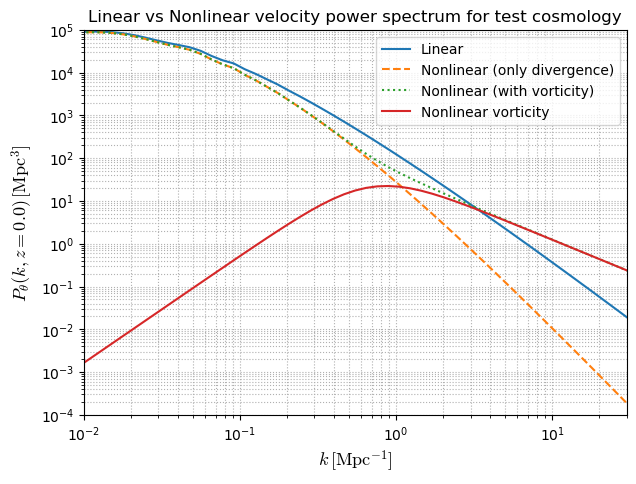

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams['mathtext.fontset'] = 'cm'

# --- Plot ---
plt.figure(figsize=(7,5))
plt.loglog(k_array, Pk_theta_lin, label='Linear', color='C0')
plt.loglog(k_array, Pk_theta_nl, label='Nonlinear (only divergence)', color='C1', linestyle='--')
plt.loglog(k_array, Pk_full_nl, label='Nonlinear (with vorticity)', color='C2', linestyle=':')
plt.loglog(k_array, Pk_full_nl-Pk_theta_nl, label='Nonlinear vorticity', color='C3', linestyle='-')

plt.xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$', fontsize=13)
#correct below
#plt.ylabel(r'$P_\theta(k, z=)\, [{\mathrm Mpc}^3/h^3]$'.format(z_plot), fontsize=13)
plt.ylabel(r'$P_\theta(k, z='+str(z_plot)+')\, [\mathrm{Mpc}^3]$', fontsize=13)
plt.title('Linear vs Nonlinear velocity power spectrum for test cosmology')
plt.legend()
plt.xlim([1.0e-2, 30.0])
plt.ylim([1.0e-4, 1e5])
plt.grid(True, which='both', ls=':')
plt.show()

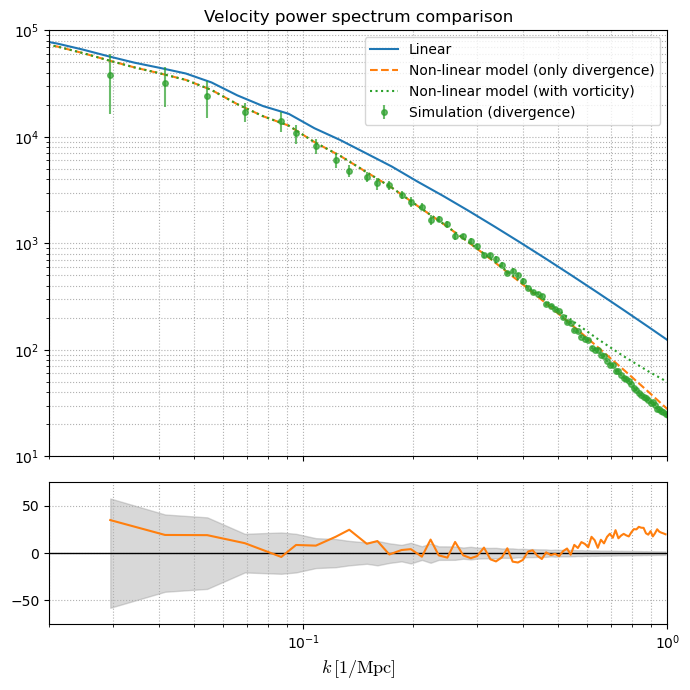

In [16]:
path_to_gevolution_outputs = 'sim-data/fixed_ics/test-sim-As-fid-h0.6/'

results_test = read_gevolution_outputs(path_to_gevolution_outputs, h_test)

# Check that the requested redshift exists
if z_plot not in results_test:
    raise ValueError(
        f"Redshift z = {z_plot} is not available in the simulation dataset. "
        f"Available redshifts are: {sorted(results_test.keys())}"
    )

k_sim = results_test[z_plot]["k_vort"]*h_test
Pk_theta_sim = results_test[z_plot]["Pk_theta"] / (Hconf_test * f_growth_test)**2/h_test**3
Nk_theta_sim = results_test[z_plot]["Nk_theta"]

sigma_pktheta = np.sqrt(2.0 / Nk_theta_sim) * Pk_theta_sim

kmax_sim = 1.0
mask = k_sim <= kmax_sim

k_sim_cut = k_sim[mask]
Pk_theta_sim_cut = Pk_theta_sim[mask]
sigma_pktheta_cut = sigma_pktheta[mask]

# --- Interpolate model onto simulation k if needed ---
# (only needed if k_array != k_sim)
Pk_theta_nl_on_sim = np.interp(
    k_sim_cut,
    k_array,
    Pk_theta_nl
)

# --- Relative difference ---
rel_diff = (Pk_theta_nl_on_sim - Pk_theta_sim_cut) / Pk_theta_sim_cut
# --- Figure with two panels ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,7), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# =======================
# Top panel: Power spectra
# =======================
ax1.plot(k_array, Pk_theta_lin, label='Linear', color='C0')
ax1.plot(k_array, Pk_theta_nl, label='Non-linear model (only divergence)', color='C1', linestyle='--')
ax1.plot(k_array, Pk_full_nl, label='Non-linear model (with vorticity)', color='C2', linestyle=':')

ax1.errorbar(
    k_sim, Pk_theta_sim, yerr=sigma_pktheta,
    fmt='o', label='Simulation (divergence)',
    color='C2', markersize=4, alpha=0.7
)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(0.02, 1.0)
ax1.set_ylim(1e1, 1e5)

#ax1.set_ylabel(r'$P_{\theta\theta}(k, z='+str(z_plot)+')$ [units where linear = matter]', fontsize=13)
ax1.set_title('Velocity power spectrum comparison')
ax1.legend()
ax1.grid(True, which='both', ls=':')

# =======================
# Bottom panel: Relative difference
# =======================
ax2.axhline(0, color='k', linestyle='-', linewidth=1)

ax2.plot(k_sim_cut, 100*rel_diff, color='C1')
ax2.fill_between(
    k_sim_cut,
    -100.0*sigma_pktheta_cut / Pk_theta_sim_cut,
    100.0*sigma_pktheta_cut / Pk_theta_sim_cut,
    color='gray', alpha=0.3, label='Simulation error'
)

ax2.set_xscale('log')
ax2.set_xlim(0.02, 1.0)

ax2.set_xlabel(r'$k\,[1/\mathrm{Mpc}]$', fontsize=13)
#ax2.set_ylabel(r'$(\mathrm{Model - Sim})/\mathrm{Sim}\,[\%]$', fontsize=13)
ax2.grid(True, which='both', ls=':')

ax2.set_ylim(-75, 75)

plt.tight_layout()
plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

# Redshift and scales
z_plot = 0.0
k_array = np.logspace(-5, 2, 100)

# Range of omega_cdm values
omega_vals = np.linspace(0.05, 0.3, 10)

# Containers
Pk_lin_all = []
Pk_nl_all = []

# --- Precompute interpolators (only once) ---
pktheta_fid_interp = get_pktheta_interpolator(params_fid, z_vals=np.linspace(0, 2.5, 50))

for omega_val in omega_vals:

    print(f"Running omega_cdm = {omega_val:.3f}")

    # --- Update cosmology ---
    params_loop = params_fid.copy()
    params_loop["omega_cdm"] = omega_val

    # --- Linear model ---
    cosmo = Class()
    cosmo.set(params_loop)
    cosmo.compute()

    Pk_lin = np.array([cosmo.pk_lin(k, z_plot) for k in k_array])
    Pk_lin_all.append(Pk_lin)

    cosmo.struct_cleanup()
    cosmo.empty()

    # --- Interpolator for this omega_cdm ---
    params_omega = params_fid.copy()
    params_omega["omega_cdm"] = omega_val

    pktheta_omega_interp = get_pktheta_interpolator(
        params_omega,
        z_vals=np.linspace(0, 2.5, 50)
    )

    # --- Nonlinear model ---
    Pk_nl = Pk_ref_nl_mod(
        k_array,
        z_plot,
        h=h_ref,
        omega_cdm=omega_val,
        pktheta_fid_interp=pktheta_fid_interp,
        pktheta_omega_cdm_interp=pktheta_omega_interp,
        A_s_ref=A_s_ref,
        omega_cdm_ref=omega_cdm_ref,
        h_ref=h_ref,
        include_vort = True,
        deriv=False#, deriv_interp=deriv_arg
    )

    Pk_nl_all.append(Pk_nl)

Pk_lin_all = np.array(Pk_lin_all)
Pk_nl_all = np.array(Pk_nl_all)

print("Model evaluation complete.")

Running omega_cdm = 0.050
Running omega_cdm = 0.078
Running omega_cdm = 0.106
Running omega_cdm = 0.133
Running omega_cdm = 0.161


/Users/flepori/Desktop/Velocity/github/velocity_power_spectrum/velocity_model.py:502: RuntimeWarning: overflow encountered in exp
  return 2.0 / (1.0 + np.exp(k / k_NL))


Running omega_cdm = 0.189
Running omega_cdm = 0.217
Running omega_cdm = 0.244
Running omega_cdm = 0.272
Running omega_cdm = 0.300
Model evaluation complete.


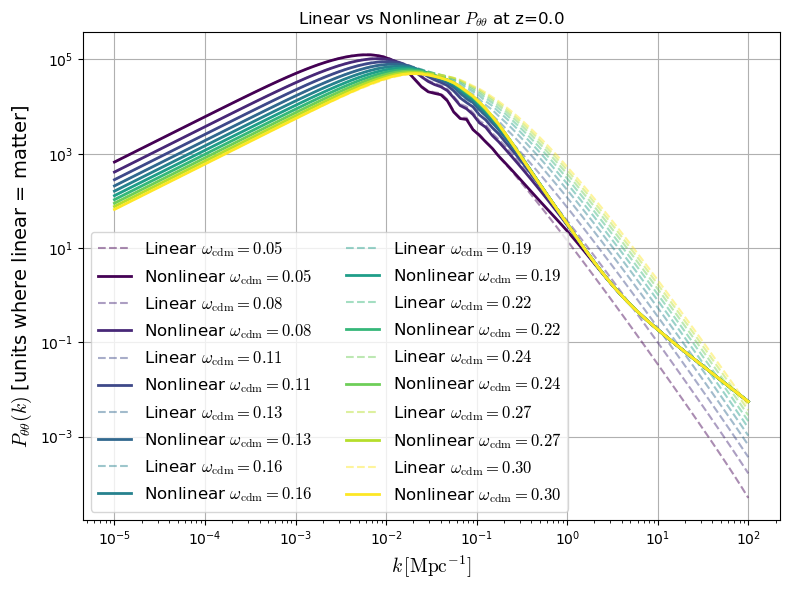

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

colors = cm.viridis(np.linspace(0, 1, len(omega_vals)))

plt.figure(figsize=(8,6))

for i, omega_val in enumerate(omega_vals):

    base_color = colors[i]

    # Linear (lighter)
    plt.loglog(
        k_array,
        Pk_lin_all[i],
        linestyle="--",
        color=base_color,
        alpha=0.45,
        label=f"Linear $\\omega_\\mathrm{{cdm}}={omega_val:.2f}$"
    )

    # Nonlinear (darker)
    plt.loglog(
        k_array,
        Pk_nl_all[i],
        linestyle="-",
        color=base_color,
        alpha=1.0,
        linewidth=2,
        label=f"Nonlinear $\\omega_\\mathrm{{cdm}}={omega_val:.2f}$"
    )

plt.xlabel(r"$k \,[{\rm Mpc}^{-1}]$", fontsize=14)
plt.ylabel(r"$P_{\theta\theta}(k)$ [units where linear = matter]", fontsize=14)
plt.title(f"Linear vs Nonlinear $P_{{\\theta\\theta}}$ at z={z_plot}")

plt.legend(ncol=2, fontsize=12)
plt.grid(True)
plt.tight_layout()

plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

# Redshift and scales
z_plot = 0.0
#compte_derivatives = True
k_array = np.logspace(-5, 2, 100)

# Range of h values
h_vals = np.linspace(0.5, 0.9, 10)

# Containers
Pk_lin_all = []
Pk_nl_all = []

# --- Precompute fiducial interpolator ---
pktheta_fid_interp = get_pktheta_interpolator(
    params_fid, 
    z_vals=np.linspace(0, 2.5, 50)
)

# --- Interpolator for this h ---
params_omega_cdm = params_fid.copy()
params_omega_cdm["omega_cdm"] = omega_cdm_ref

pktheta_omega_cdm_interp = get_pktheta_interpolator(
        params_omega_cdm,
        z_vals=np.linspace(0, 2.5, 50)
)

for h_val in h_vals:

    print(f"Running h = {h_val:.3f}")

    # --- Update cosmology ---
    params_loop = params_fid.copy()
    params_loop["h"] = h_val
    params_loop["omega_cdm"] = omega_cdm_ref

    # --- Linear model ---
    cosmo = Class()
    cosmo.set(params_loop)
    cosmo.compute()

    Pk_lin = np.array([cosmo.pk_lin(k, z_plot) for k in k_array])
    Pk_lin_all.append(Pk_lin)

    cosmo.struct_cleanup()
    cosmo.empty()
 
    # --- Nonlinear model ---
    Pk_nl = Pk_ref_nl_mod(
        k_array,
        z_plot,
        h=h_val,
        omega_cdm=omega_cdm_ref,
        pktheta_fid_interp=pktheta_fid_interp,
        pktheta_omega_cdm_interp=pktheta_omega_cdm_interp,
        A_s_ref=A_s_ref,
        omega_cdm_ref=omega_cdm_ref,
        h_ref=h_ref,
        include_vort = True,
        deriv=False#, deriv_interp=deriv_arg
    )

    Pk_nl_all.append(Pk_nl)

Pk_lin_all = np.array(Pk_lin_all)
Pk_nl_all = np.array(Pk_nl_all)

print("Model evaluation complete.")

Running h = 0.500
Running h = 0.544
Running h = 0.589
Running h = 0.633
Running h = 0.678
Running h = 0.722
Running h = 0.767
Running h = 0.811
Running h = 0.856
Running h = 0.900
Model evaluation complete.


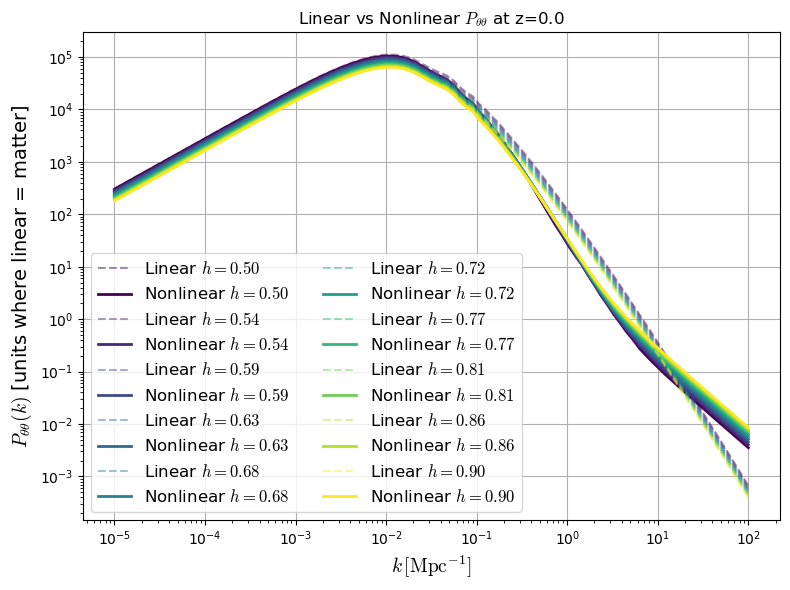

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

colors = cm.viridis(np.linspace(0, 1, len(h_vals)))

plt.figure(figsize=(8,6))

for i, h_val in enumerate(h_vals):

    base_color = colors[i]

    # Linear (lighter)
    plt.loglog(
        k_array,
        Pk_lin_all[i],
        linestyle="--",
        color=base_color,
        alpha=0.45,
        label=f"Linear $h={h_val:.2f}$"
    )

    # Nonlinear (darker)
    plt.loglog(
        k_array,
        Pk_nl_all[i],
        linestyle="-",
        color=base_color,
        alpha=1.0,
        linewidth=2,
        label=f"Nonlinear $h={h_val:.2f}$"
    )

plt.xlabel(r"$k \,[{\rm Mpc}^{-1}]$", fontsize=14)
plt.ylabel(r"$P_{\theta\theta}(k)$ [units where linear = matter]", fontsize=14)
plt.title(f"Linear vs Nonlinear $P_{{\\theta\\theta}}$ at z={z_plot}")

plt.legend(ncol=2, fontsize=12)
plt.grid(True)
plt.tight_layout()

plt.show()